In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

In [2]:
engData = pd.read_csv('./data/eng_data.csv')

In [3]:
print(engData.head().to_markdown())

|    | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location    |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  0 | 2023-01-01 08:00:00 |            1127 |           4 | 95071.9  | H          | Purchase          | Tokyo       |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        0 |
|  1 | 2023-01-01 08:01:00 |            1639 |          10 | 15607.9  | H          | Purchase          | London      |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        1 |
|  2 | 2023-01-01 08:02:00 |             872 |           8 | 65092.3  | E          | Withdrawal        | London      |   202

In [4]:
print(engData[engData['TransactionType'] == 'Transfer'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Transfer']['Merchant'].unique())

print(engData[engData['TransactionType'] == 'Withdrawal'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Withdrawal']['Merchant'].unique())

print(engData[engData['TransactionType'] == 'Purchase'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Purchase']['Merchant'].unique())


|    | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location      |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:--------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  5 | 2023-01-01 08:05:00 |            1083 |          15 | 13958    | C          | Transfer          | London        |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        5 |
|  6 | 2023-01-01 08:06:00 |             832 |           9 |  4654.58 | C          | Transfer          | Tokyo         |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        6 |
|  8 | 2023-01-01 08:08:00 |             777 |          10 |  9776.23 | D          | Transfer          | London     

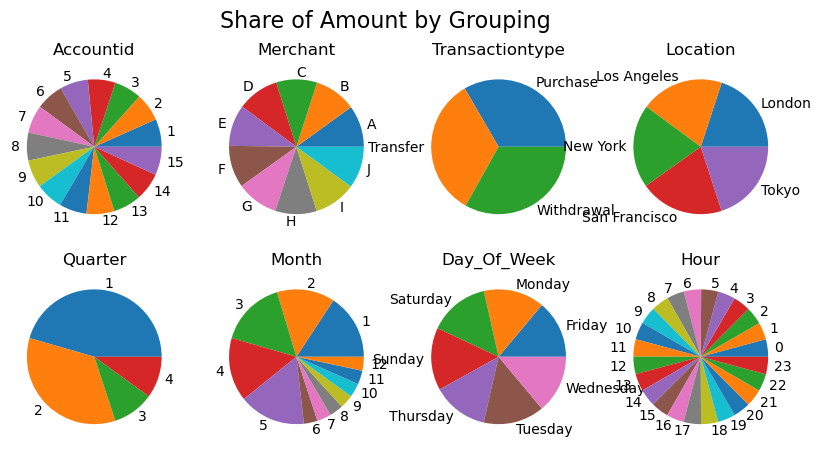

In [5]:
# Check for Amount Sum across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()

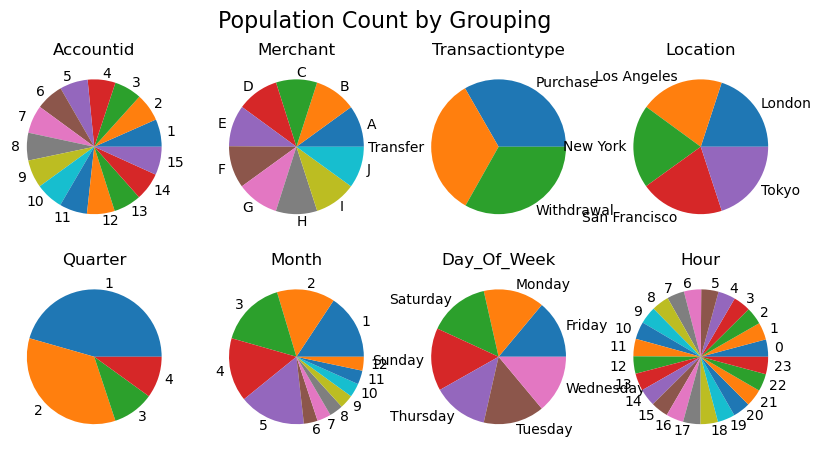

In [6]:
# Check for Population Balance across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].count()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Population Count by Grouping', fontsize=16)
plt.show()

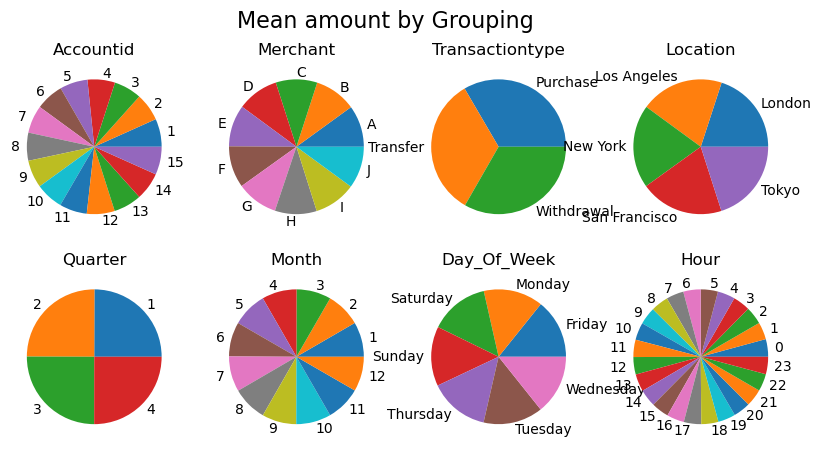

In [19]:
# Mean Amount by grouping
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].mean()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Mean amount by Grouping', fontsize=16)
plt.show()

In [ ]:
# Outlier Detection
def find_outliers_zscore(series, threshold=2.5):
    z_scores = zscore(series)
    outliers = series[abs(z_scores) > threshold]
    return outliers


outliers_zscore = find_outliers_zscore(engData['Amount'])
print("\nOutliers using Z-score method (threshold=3):")
print(outliers_zscore.index)


def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers


outliers_iqr = find_outliers_iqr(engData['Amount'])
print("\nOutliers using IQR method:")
print(outliers_iqr.index)

outliers = engData.iloc[outliers_iqr.index]
print(outliers.to_markdown())

# We need to examine these outliers closely.


Outliers using Z-score method (threshold=3):
Index([  2775,   3448,   3453,   4148,   4194,  45099,  45100, 211714, 211753,
       211866, 211959, 212513, 213460],
      dtype='int64')

Outliers using IQR method:
Index([2775, 3448, 3453, 4148, 4194, 45099, 45100, 211753, 211866, 211959,
       213460],
      dtype='int64')
|        | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location      |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   minute |   Minute |
|-------:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:--------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|---------:|
|   2775 | 2023-03-01 06:15:00 |            1049 |          14 |   978942 | J          | Transfer          | New York      |   2023 |         1 |       3 | Wednesday     |              1 |            60

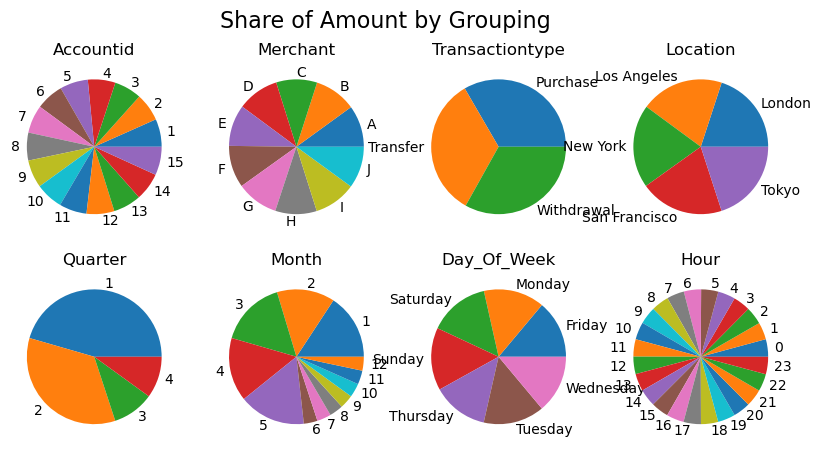

In [ ]:
# replot distribution without outliers
sans_outliers = engData.drop(index=outliers.index)

# Check for Amount Sum across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = sans_outliers.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()
# Removing the outliers had no significant impact on share of Amount

In [ ]:
# How many records have a whole-number for their amount?
whole_number_rows = engData[(engData['Amount'] % 1 == 0)]
print(len(whole_number_rows))
# print(whole_number_rows.to_markdown())

#  Whole Number rows seem to be 1/10th of the data set, this is congruent with Benford's Law findings below... 

2195


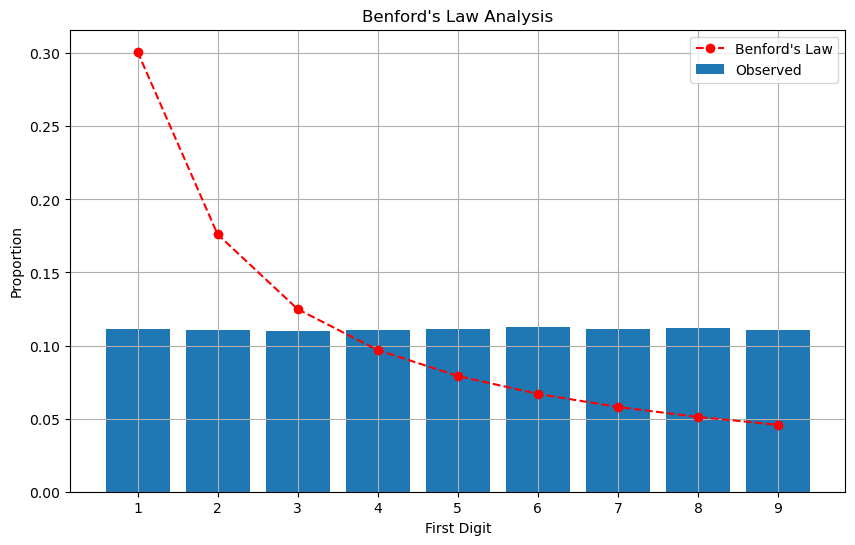

In [42]:
# Check Benford's law for Amount (https://en.wikipedia.org/wiki/Benford%27s_law)
benData = engData.copy()
benData['first_digit'] = benData['Amount'].astype(str).str[0].astype(int)
observed_counts = benData['first_digit'].value_counts().sort_index()
observed_proportions = observed_counts / len(benData)
benford_expected_proportions = pd.Series([np.log10(1 + 1/d) for d in range(1, 10)], index=range(1, 10))

plt.figure(figsize=(10, 6))
plt.bar(observed_proportions.index, observed_proportions.values, label='Observed')
plt.plot(benford_expected_proportions.index, benford_expected_proportions.values, color='red', marker='o', linestyle='--', label='Benford\'s Law')
plt.xlabel('First Digit')
plt.ylabel('Proportion')
plt.title('Benford\'s Law Analysis')
plt.legend()
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

# According to Benford's Law, these books have been cooked !!!!!
# Graph indicates presence of anomalies or potential data manipulation